# Analyzation of the optimization case4 results

---
## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

# ── aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

LIGAND_PALETTE = {
    "XPhos": "#1f77b4", "SPhos": "#ff7f0e", "RuPhos": "#2ca02c",
    "AmPhos": "#d62728", "PCy3": "#9467bd", "PPh3": "#8c564b", "tBu3": "#e377c2"
}

# ── load data ────────────────────────────────────────────────────────────────
CSV_PATH = r"OPTIMIZATION-case4-PREDICTIONS.csv"   # adjust path if needed
df = pd.read_csv(CSV_PATH)

# tidy types
df["ligand"]        = df["ligand"].astype("category")
df["out_of_domain"] = df["out_of_domain"].astype(bool)

print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
df.head()

Loaded 2,380 rows × 18 columns


,temp_c,ligand,cat_loading,time_s,dG_OA,dG_TM,G_OA_TS,G_TM_TS,dG_boron_hydrolysis,G_Substrate,G_boron_species,k_OA,k_TM,dG_PdLArOH,G_precatalyst,predicted_yield,nn_distance,out_of_domain
0,75,XPhos,2.5,300,9.168911,10.629964,-1.545785e+06,-1.763872e+06,0.0,-444182.577714,-459278.631218,1.273461e+07,1.541123e+06,10.649906,-1843172.349,99.82000,0.826342,False
1,80,XPhos,2.5,300,9.413957,10.641156,-1.545787e+06,-1.763873e+06,0.0,-444182.977724,-459279.306962,1.099064e+07,1.912403e+06,10.649906,-1843173.979,99.55055,0.830800,False
2,75,XPhos,2.5,600,9.168911,10.629964,-1.545785e+06,-1.763872e+06,0.0,-444182.577714,-459278.631218,1.273461e+07,1.541123e+06,10.649906,-1843172.349,99.02913,1.221677,False
3,75,XPhos,2.5,900,9.168911,10.629964,-1.545785e+06,-1.763872e+06,0.0,-444182.577714,-459278.631218,1.273461e+07,1.541123e+06,10.649906,-1843172.349,99.02913,1.926726,False
4,80,XPhos,2.5,600,9.413957,10.641156,-1.545787e+06,-1.763873e+06,0.0,-444182.977724,-459279.306962,1.099064e+07,1.912403e+06,10.649906,-1843173.979,98.71952,1.223568,False


---
## 1. Dataset Overview

In [9]:
print("=== Basic statistics ===")
df.describe().T.style.format("{:.3f}").background_gradient(axis=1, cmap="Blues")

=== Basic statistics ===


,count,mean,std,min,25%,50%,75%,max
temp_c,2380.000,70.000,24.500,30.000,50.000,70.000,90.000,110.000
cat_loading,2380.000,2.312,1.709,0.500,1.062,1.875,3.125,5.000
time_s,2380.000,402.000,309.283,60.000,150.000,300.000,600.000,900.000
dG_OA,2380.000,9.553,4.133,4.453,6.207,7.765,12.755,19.418
dG_TM,2380.000,10.312,4.706,2.266,5.880,10.619,15.623,15.925
G_OA_TS,2380.000,-1345657.545,195236.925,-1566254.535,-1545778.517,-1448656.048,-1174569.326,-1035497.448
G_TM_TS,2380.000,-1563739.389,195238.456,-1784341.402,-1763862.994,-1666737.966,-1392654.503,-1253573.552
dG_boron_hydrolysis,2380.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
G_Substrate,2380.000,-444182.202,1.946,-444185.416,-444183.783,-444182.180,-444180.605,-444179.061
G_boron_species,2380.000,-459278.020,3.274,-459283.465,-459280.673,-459277.960,-459275.327,-459272.775


In [4]:
print("=== Grid coverage ===")
print(f"  Ligands       : {df['ligand'].nunique()} → {sorted(df['ligand'].unique())}")
print(f"  Temperatures  : {df['temp_c'].nunique()} levels → {sorted(df['temp_c'].unique())} °C")
print(f"  Cat. loading  : {df['cat_loading'].nunique()} levels → {sorted(df['cat_loading'].unique())} mol%")
print(f"  Time          : {df['time_s'].nunique()} levels → {sorted(df['time_s'].unique())} s")
print()
print("=== Domain flags ===")
print(df["out_of_domain"].value_counts().rename({False: "In-domain", True: "Out-of-domain"}))
print()
print("=== Predicted yield summary ===")
print(df["predicted_yield"].describe())

=== Grid coverage ===
  Ligands       : 7 → ['AmPhos', 'PCy3', 'PPh3', 'RuPhos', 'SPhos', 'XPhos', 'tBu3']
  Temperatures  : 17 levels → [np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(95), np.int64(100), np.int64(105), np.int64(110)] °C
  Cat. loading  : 4 levels → [np.float64(0.5), np.float64(1.25), np.float64(2.5), np.float64(5.0)] mol%
  Time          : 5 levels → [np.int64(60), np.int64(150), np.int64(300), np.int64(600), np.int64(900)] s

=== Domain flags ===
out_of_domain
In-domain        1194
Out-of-domain    1186
Name: count, dtype: int64

=== Predicted yield summary ===
count    2380.000000
mean       40.562910
std        27.381964
min        -5.000155
25%        19.628748
50%        33.260506
75%        59.452842
max        99.820000
Name: predicted_yield, dtype: float64


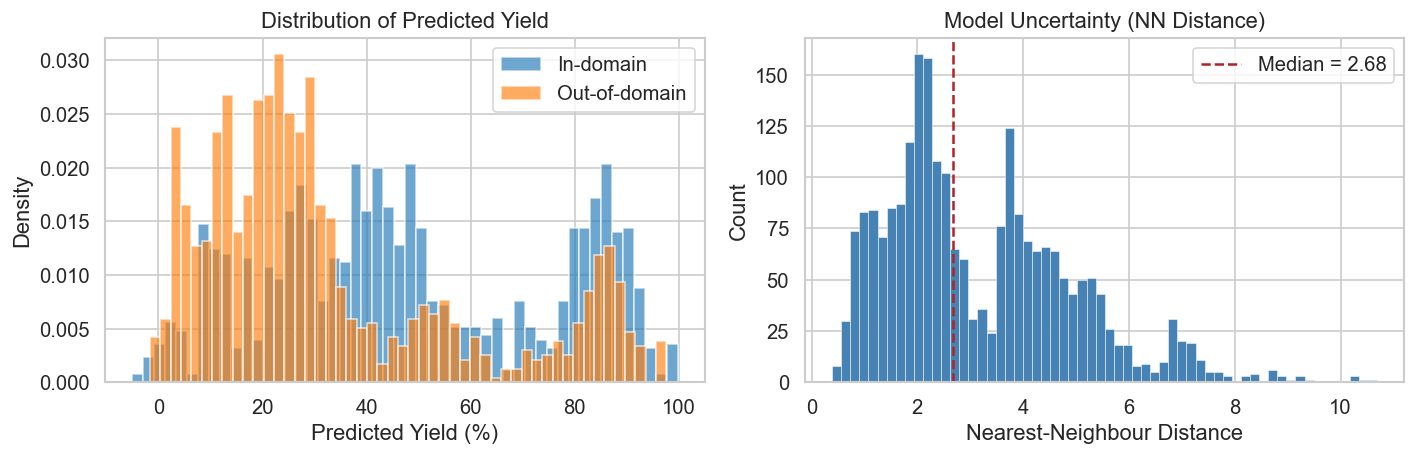

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Yield distribution
ax = axes[0]
for in_dom, grp in df.groupby("out_of_domain"):
    label = "Out-of-domain" if in_dom else "In-domain"
    ax.hist(grp["predicted_yield"], bins=50, alpha=0.65, label=label, density=True)
ax.set_xlabel("Predicted Yield (%)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Predicted Yield")
ax.legend()

# nn_distance distribution
ax = axes[1]
ax.hist(df["nn_distance"], bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(df["nn_distance"].median(), color="firebrick", linestyle="--", label=f"Median = {df['nn_distance'].median():.2f}")
ax.set_xlabel("Nearest-Neighbour Distance")
ax.set_ylabel("Count")
ax.set_title("Model Uncertainty (NN Distance)")
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\livio\AppData\Local\Temp\ipykernel_37928\2554397076.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df["predicted_yield"], bins=30, edgecolor="0.2", linewidth=0.8, palette="deep", kde=True)


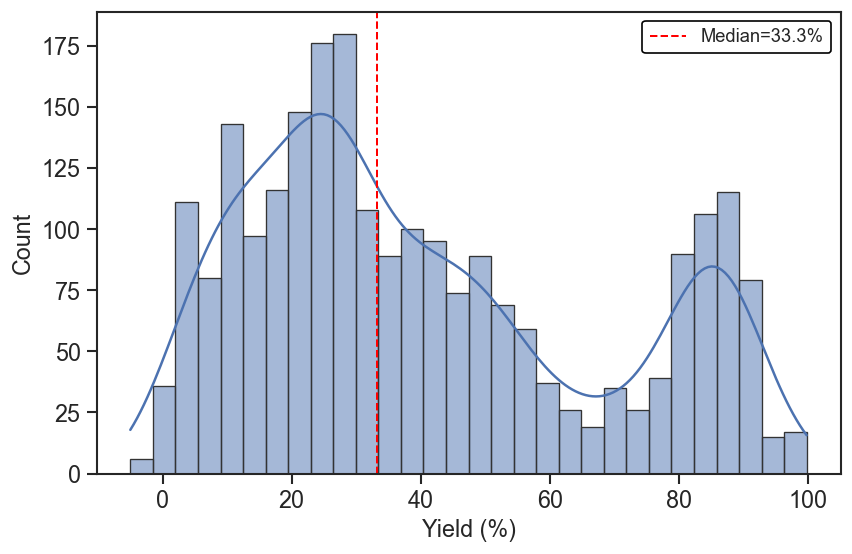

In [21]:
sns.set_theme(style="ticks")
sns.color_palette()
f, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["predicted_yield"], bins=30, edgecolor="0.2", linewidth=0.8, palette="deep", kde=True)
ax.axvline(df["predicted_yield"].median(), color="red", linestyle="--", linewidth=1.2, label=f"Median={df['predicted_yield'].median():.1f}%")
# ax.set_title("Yield Distribution")
ax.set_xlabel("Yield (%)", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
ax.tick_params(axis='both', labelsize=14)
legend = ax.legend(
    facecolor='white',      # Solid white background
    edgecolor='black',      # Black border
    framealpha=1,           # Fully opaque
    fancybox=True,          # Rounding of the box
)

---
## 2. Top Candidates

In [10]:
# ── Top 20 predictions (all) ──────────────────────────────────────────────
top20 = df.nlargest(20, "predicted_yield")[
    ["ligand", "temp_c", "cat_loading", "time_s",
     "predicted_yield", "nn_distance", "out_of_domain"]
].reset_index(drop=True)

print("=== Top 20 predictions ===")
top20.style.background_gradient(subset=["predicted_yield"], cmap="Greens") \
           .background_gradient(subset=["nn_distance"],     cmap="Reds_r")

=== Top 20 predictions ===


,ligand,temp_c,cat_loading,time_s,predicted_yield,nn_distance,out_of_domain
0,XPhos,75,2.500000,300,99.820000,0.826342,False
1,XPhos,80,2.500000,300,99.550550,0.830800,False
2,XPhos,75,2.500000,600,99.029130,1.221677,False
3,XPhos,75,2.500000,900,99.029130,1.926726,False
4,XPhos,80,2.500000,600,98.719520,1.223568,False
5,XPhos,80,2.500000,900,98.719520,1.908572,False
6,XPhos,85,2.500000,300,98.699936,0.828558,False
7,XPhos,85,2.500000,600,97.993090,1.232548,False
8,XPhos,85,2.500000,900,97.993090,1.907798,False
9,XPhos,75,5.000000,300,97.643390,3.656095,True


In [11]:
# ── Top 20 IN-DOMAIN predictions (reliable) ──────────────────────────────
top20_id = df[df["out_of_domain"] == False].nlargest(20, "predicted_yield")[
    ["ligand", "temp_c", "cat_loading", "time_s",
     "predicted_yield", "nn_distance"]
].reset_index(drop=True)

print("=== Top 20 IN-DOMAIN predictions ===")
top20_id.style.background_gradient(subset=["predicted_yield"], cmap="Greens") \
              .background_gradient(subset=["nn_distance"],     cmap="Reds_r")

=== Top 20 IN-DOMAIN predictions ===


,ligand,temp_c,cat_loading,time_s,predicted_yield,nn_distance
0,XPhos,75,2.500000,300,99.820000,0.826342
1,XPhos,80,2.500000,300,99.550550,0.830800
2,XPhos,75,2.500000,600,99.029130,1.221677
3,XPhos,75,2.500000,900,99.029130,1.926726
4,XPhos,80,2.500000,600,98.719520,1.223568
5,XPhos,80,2.500000,900,98.719520,1.908572
6,XPhos,85,2.500000,300,98.699936,0.828558
7,XPhos,85,2.500000,600,97.993090,1.232548
8,XPhos,85,2.500000,900,97.993090,1.907798
9,XPhos,75,2.500000,60,96.470030,0.971772


---
## 3. Ligand Comparison

C:\Users\livio\AppData\Local\Temp\ipykernel_37928\692830644.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df.groupby("ligand")["predicted_yield"].median().sort_values(ascending=False).index
C:\Users\livio\AppData\Local\Temp\ipykernel_37928\692830644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ligand", y="predicted_yield", order=order,
C:\Users\livio\AppData\Local\Temp\ipykernel_37928\692830644.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silen

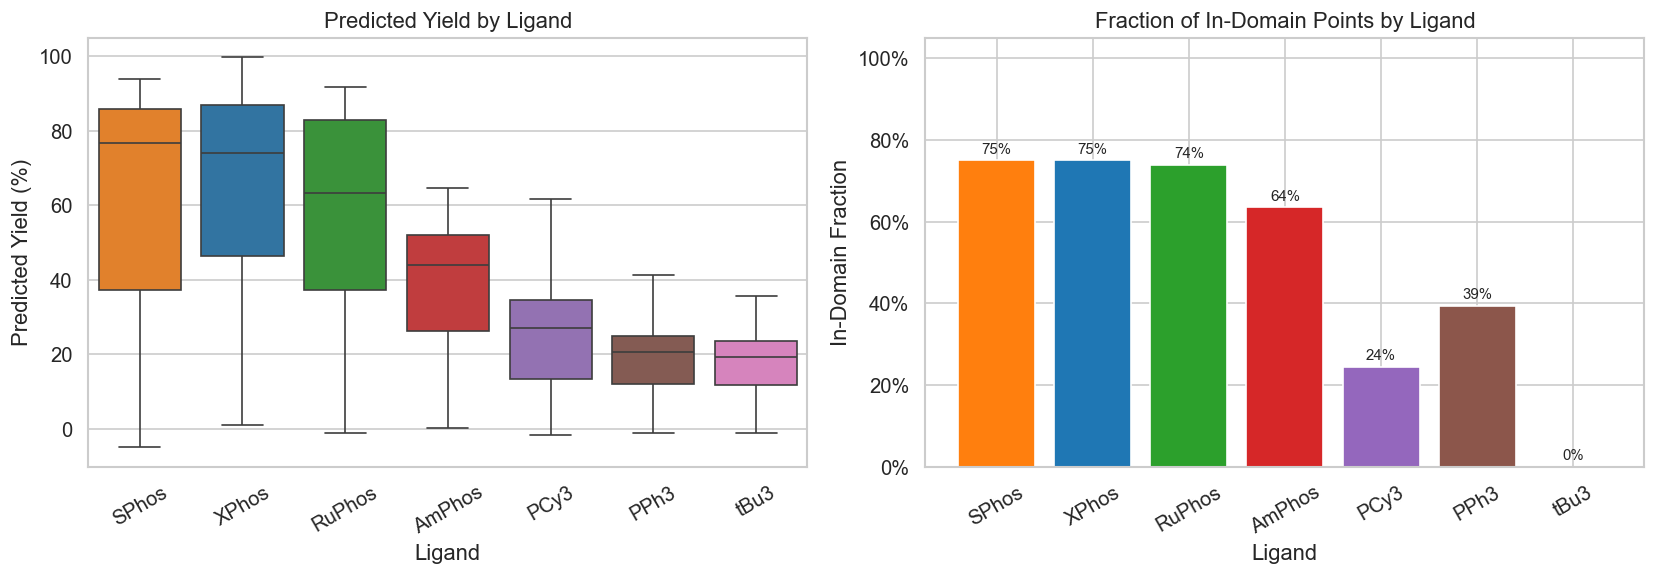

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot per ligand
ax = axes[0]
order = df.groupby("ligand")["predicted_yield"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="ligand", y="predicted_yield", order=order,
            palette=LIGAND_PALETTE, ax=ax, flierprops=dict(marker=".", alpha=0.4))
ax.set_title("Predicted Yield by Ligand")
ax.set_xlabel("Ligand")
ax.set_ylabel("Predicted Yield (%)")
ax.tick_params(axis="x", rotation=30)

# Fraction in-domain per ligand
ax = axes[1]
frac_id = df.groupby("ligand")["out_of_domain"].apply(lambda x: (~x).mean()).reindex(order)
bars = ax.bar(frac_id.index, frac_id.values,
              color=[LIGAND_PALETTE[l] for l in frac_id.index])
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Fraction of In-Domain Points by Ligand")
ax.set_xlabel("Ligand")
ax.set_ylabel("In-Domain Fraction")
ax.tick_params(axis="x", rotation=30)
for bar, v in zip(bars, frac_id.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.0%}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\livio\AppData\Local\Temp\ipykernel_37928\3620694481.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_order = df.groupby("ligand")["predicted_yield"].median().sort_values().index.tolist()
C:\Users\livio\AppData\Local\Temp\ipykernel_37928\3620694481.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ligand", y="predicted_yield",


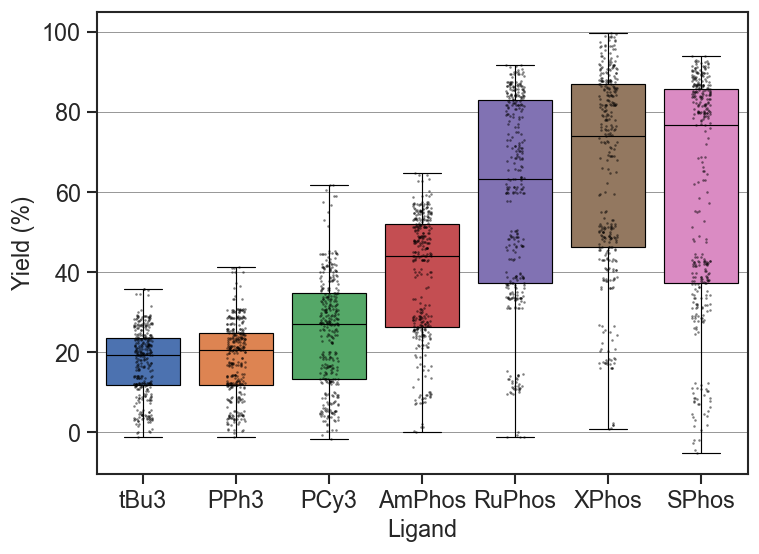

In [96]:
# Yield by catalyst
median_order = df.groupby("ligand")["predicted_yield"].median().sort_values().index.tolist()
f, ax = plt.subplots(figsize=(7, 5))
order = sorted(df["ligand"].unique())
sns.boxplot(data=df, x="ligand", y="predicted_yield", 
            linewidth=0.7, palette="deep", 
            saturation=1, linecolor="black", order=median_order)
sns.stripplot(data=df, x="ligand", y="predicted_yield", color="black", alpha=0.5, size=1.5)
# ax.set_title("Yield distribution by ligand", fontsize=14)
ax.set_ylabel("Yield (%)", fontsize=14)
ax.set_xlabel("Ligand", fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.grid(True, axis="y", linewidth=0.6, color="black", alpha=0.4)

In [13]:
# Per-ligand summary table
summary = (
    df.groupby("ligand")
    .agg(
        mean_yield        = ("predicted_yield", "mean"),
        median_yield      = ("predicted_yield", "median"),
        max_yield         = ("predicted_yield", "max"),
        std_yield         = ("predicted_yield", "std"),
        mean_nn_dist      = ("nn_distance",     "mean"),
        pct_in_domain     = ("out_of_domain",   lambda x: (~x).mean() * 100),
        n_points          = ("predicted_yield", "count"),
    )
    .sort_values("median_yield", ascending=False)
    .round(2)
)
summary.style.background_gradient(subset=["median_yield", "max_yield"], cmap="Greens")

C:\Users\livio\AppData\Local\Temp\ipykernel_37928\1329485950.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ligand")


,mean_yield,median_yield,max_yield,std_yield,mean_nn_dist,pct_in_domain,n_points
ligand,,,,,,,
SPhos,60.010000,76.730000,94.030000,28.790000,1.980000,75.000000,340
XPhos,65.300000,74.040000,99.820000,24.840000,2.040000,75.000000,340
RuPhos,58.760000,63.380000,91.710000,25.300000,2.170000,73.820000,340
AmPhos,38.850000,44.000000,64.710000,15.610000,2.830000,63.530000,340
PCy3,25.110000,27.180000,61.660000,13.600000,4.350000,24.410000,340
PPh3,18.470000,20.580000,41.210000,9.260000,3.250000,39.410000,340
tBu3,17.460000,19.280000,35.720000,8.310000,5.580000,0.000000,340


---
## 4. Effect of Reaction Conditions

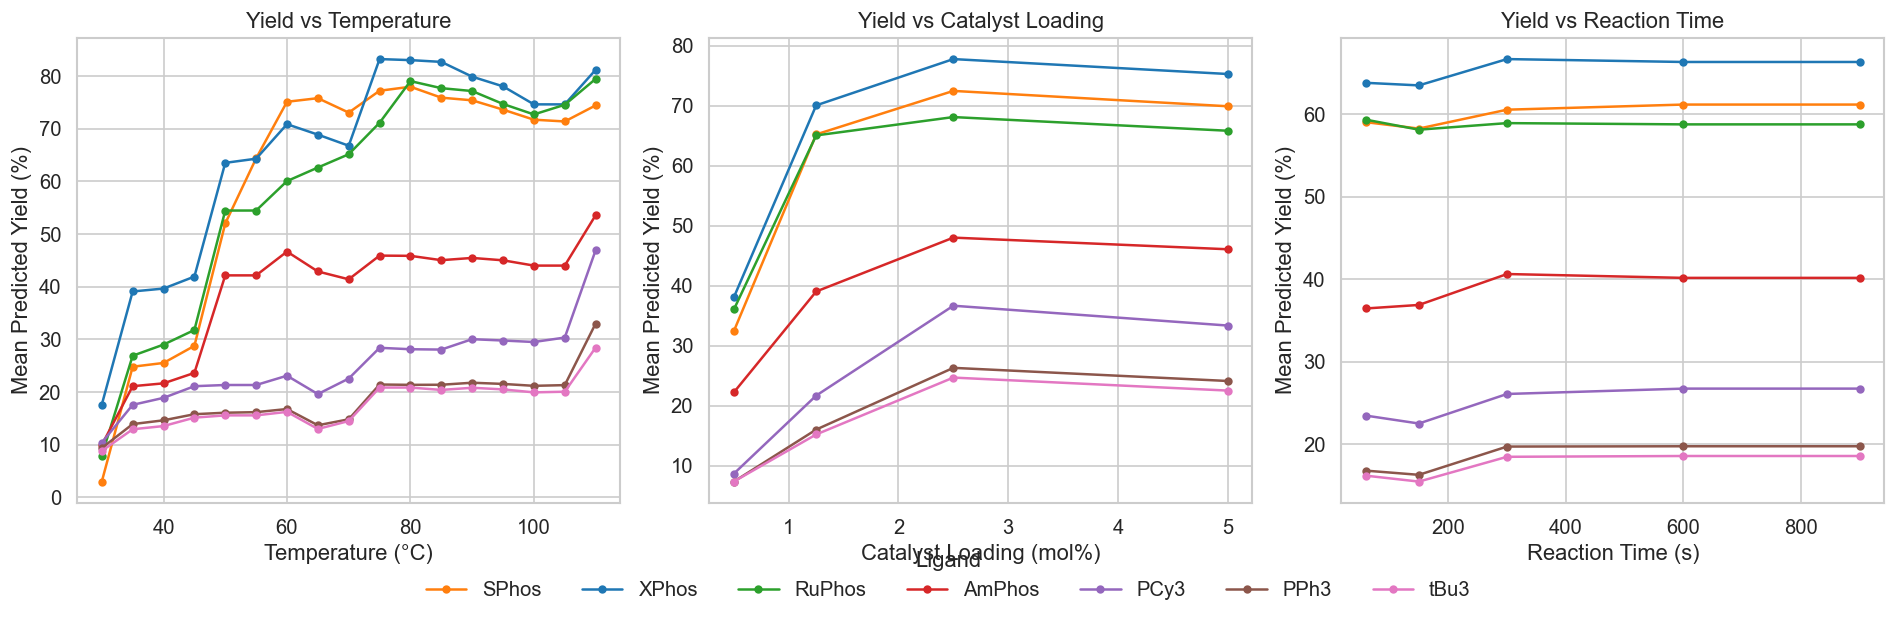

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vars_labels = [
    ("temp_c",      "Temperature (°C)"),
    ("cat_loading", "Catalyst Loading (mol%)"),
    ("time_s",      "Reaction Time (s)"),
]

for ax, (var, label) in zip(axes, vars_labels):
    for lig in order:
        grp = df[df["ligand"] == lig].groupby(var)["predicted_yield"].mean()
        ax.plot(grp.index, grp.values, marker="o", markersize=4,
                color=LIGAND_PALETTE[lig], label=lig, linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel("Mean Predicted Yield (%)")
    ax.set_title(f"Yield vs {label.split('(')[0].strip()}")

# single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=7,
           bbox_to_anchor=(0.5, -0.05), title="Ligand", frameon=False)
plt.tight_layout()
plt.show()

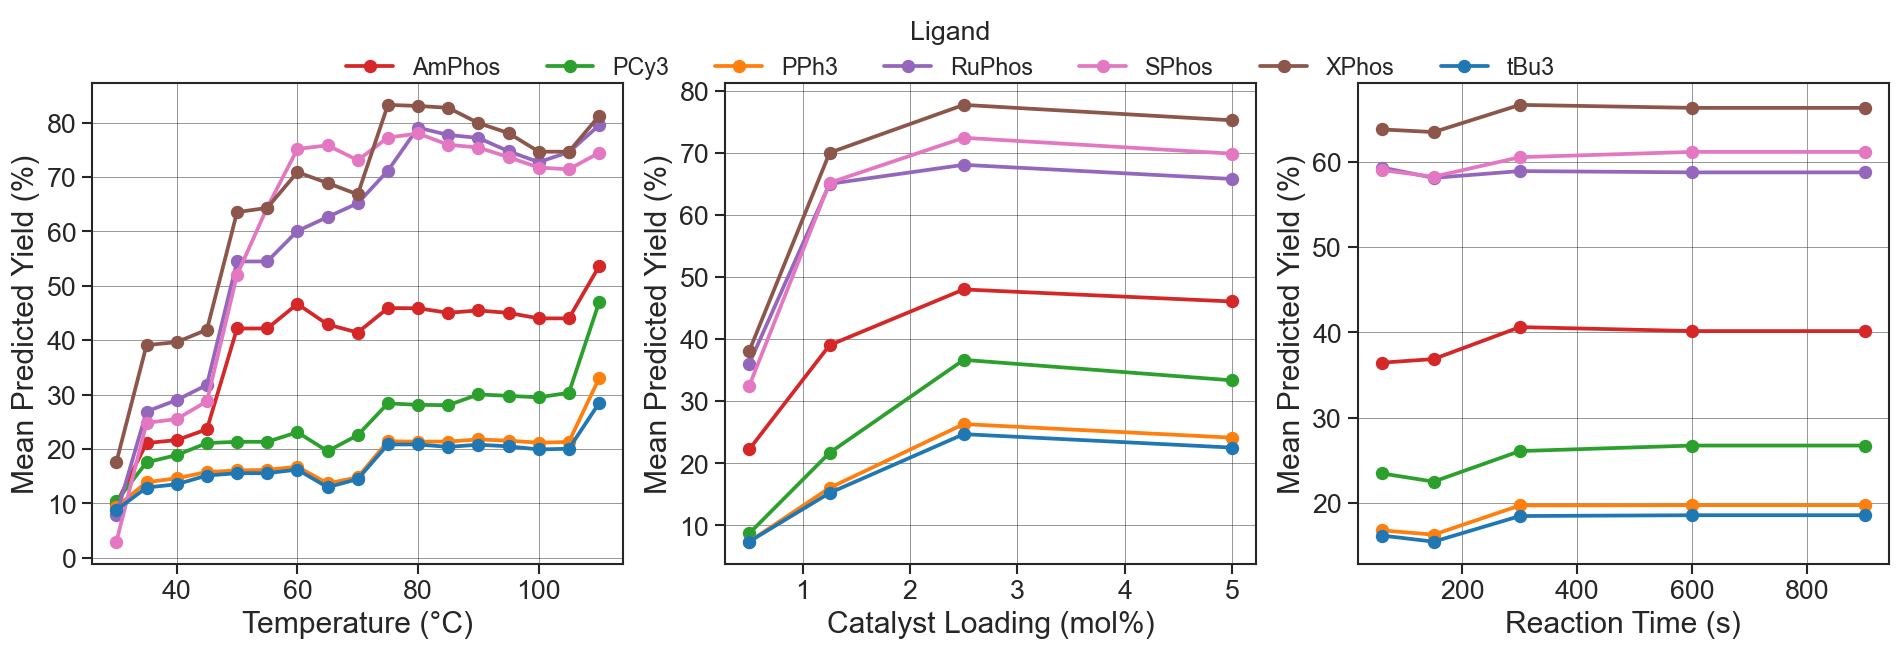

In [128]:
# Better visualization of these
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Color palette
deep = sns.color_palette("tab10")
LIGAND_PALETTE = {lig: deep[i] for i, lig in enumerate(median_order)}

vars_labels = [
    ("temp_c",      "Temperature (°C)"),
    ("cat_loading", "Catalyst Loading (mol%)"),
    ("time_s",      "Reaction Time (s)"),
]

for ax, (var, label) in zip(axes, vars_labels):
    for lig in order:
        grp = df[df["ligand"] == lig].groupby(var)["predicted_yield"].mean()
        ax.plot(grp.index, grp.values, marker="o", markersize=7,
                color=LIGAND_PALETTE[lig], label=lig, linewidth=2.25)
    ax.set_xlabel(label, fontsize=18)
    ax.set_ylabel("Mean Predicted Yield (%)", fontsize=18)
    ax.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.4)
    ax.tick_params(axis='both', labelsize=16)
    # ax.set_title(f"Yield vs {label.split('(')[0].strip()}", fontsize=14)

# single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=7,
           bbox_to_anchor=(0.5, 1.1), title="Ligand", frameon=False,
           title_fontsize=16, fontsize=14)
plt.tight_layout()
plt.show()

In [100]:
print(order)
print(LIGAND_PALETTE)

['AmPhos', 'PCy3', 'PPh3', 'RuPhos', 'SPhos', 'XPhos', 'tBu3']
{'tBu3': (0.2980392156862745, 0.4470588235294118, 0.6901960784313725), 'PPh3': (0.8666666666666667, 0.5176470588235295, 0.3215686274509804), 'PCy3': (0.3333333333333333, 0.6588235294117647, 0.40784313725490196), 'AmPhos': (0.7686274509803922, 0.3058823529411765, 0.3215686274509804), 'RuPhos': (0.5058823529411764, 0.4470588235294118, 0.7019607843137254), 'XPhos': (0.5764705882352941, 0.47058823529411764, 0.3764705882352941), 'SPhos': (0.8549019607843137, 0.5450980392156862, 0.7647058823529411)}


---
## 5. Heat Maps — Temperature × Catalyst Loading

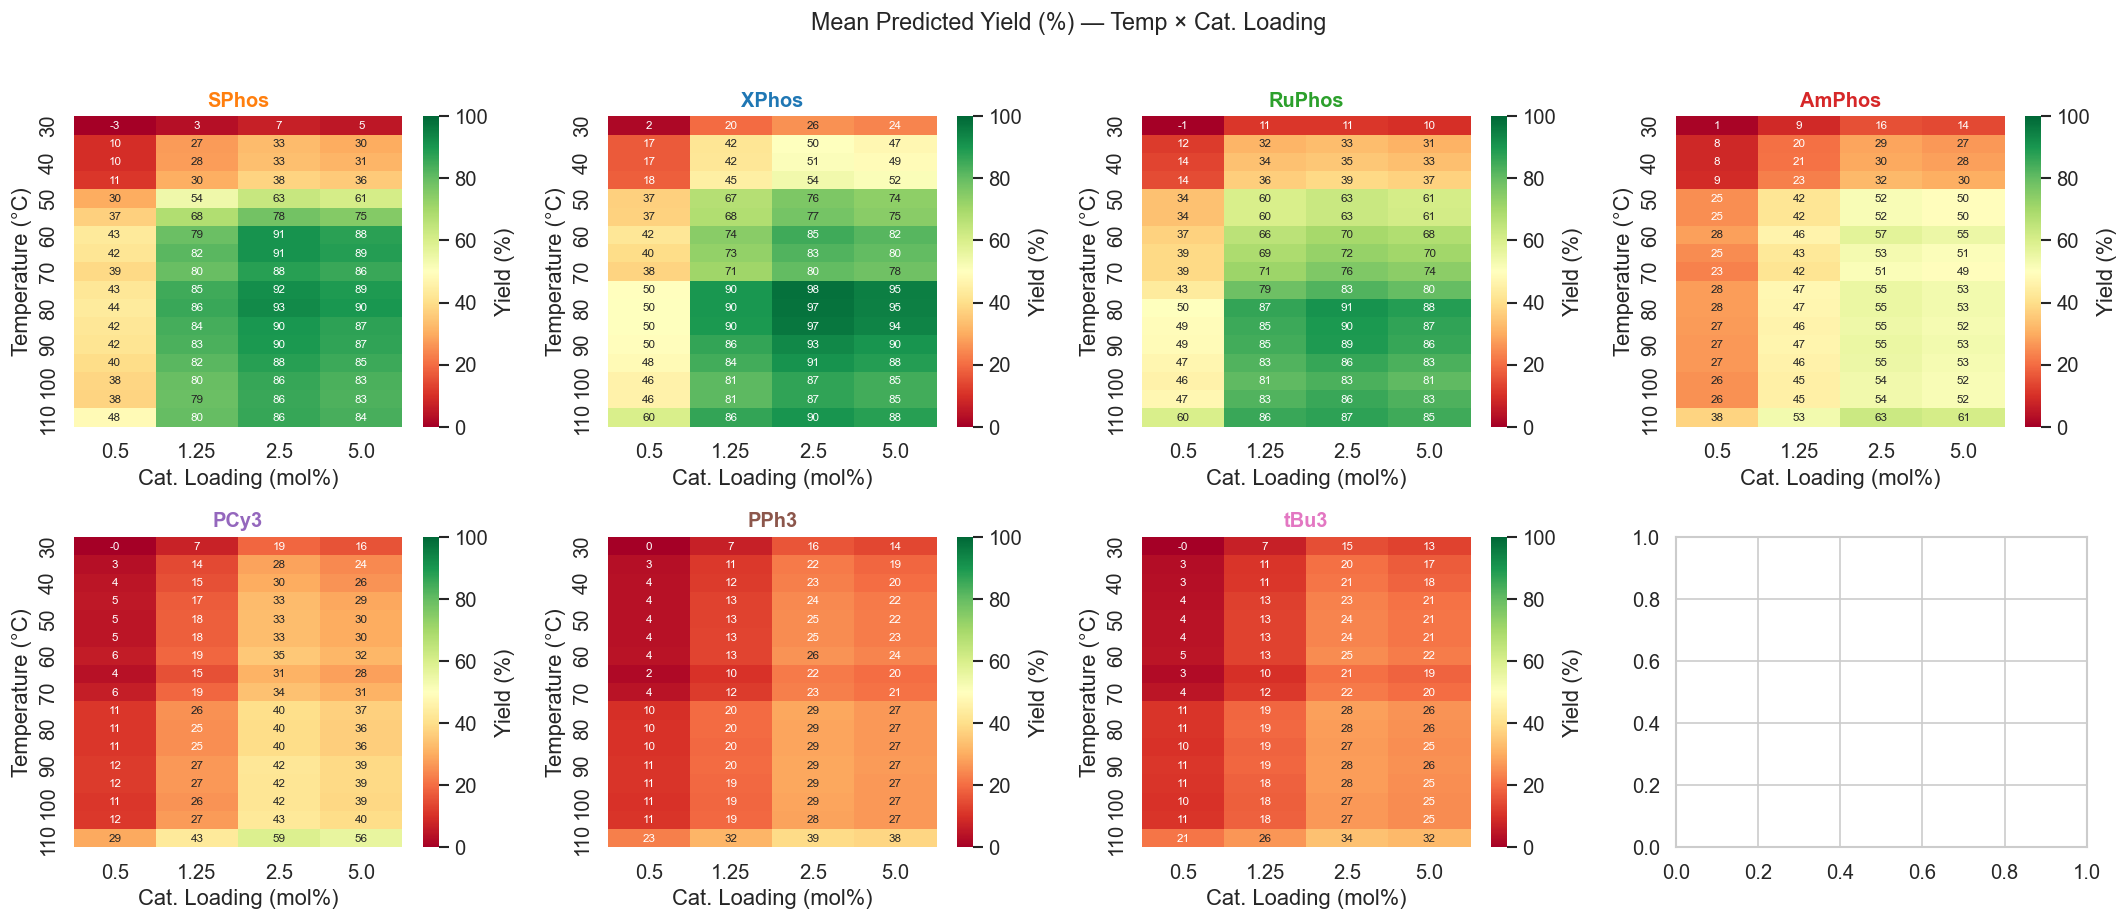

In [15]:
ligands = list(order)          # sorted by median yield
ncols = 4
nrows = -(-len(ligands) // ncols)   # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.8 * nrows))
axes_flat = axes.flat

for lig, ax in zip(ligands, axes_flat):
    pivot = (
        df[df["ligand"] == lig]
        .groupby(["temp_c", "cat_loading"])["predicted_yield"]
        .mean()
        .unstack("cat_loading")
    )
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn", vmin=0, vmax=100,
                annot=True, fmt=".0f", annot_kws={"size": 7},
                cbar_kws={"label": "Yield (%)"})
    ax.set_title(lig, fontsize=12, fontweight="bold", color=LIGAND_PALETTE[lig])
    ax.set_xlabel("Cat. Loading (mol%)")
    ax.set_ylabel("Temperature (°C)")

# hide spare axes
for ax in list(axes_flat)[len(ligands):]:
    ax.set_visible(False)

plt.suptitle("Mean Predicted Yield (%) — Temp × Cat. Loading",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Model Uncertainty Analysis

C:\Users\livio\AppData\Local\Temp\ipykernel_37928\239965778.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_nn = df.groupby("ligand")["nn_distance"].mean().reindex(order)
C:\Users\livio\AppData\Local\Temp\ipykernel_37928\239965778.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_nn  = df.groupby("ligand")["nn_distance"].std().reindex(order)


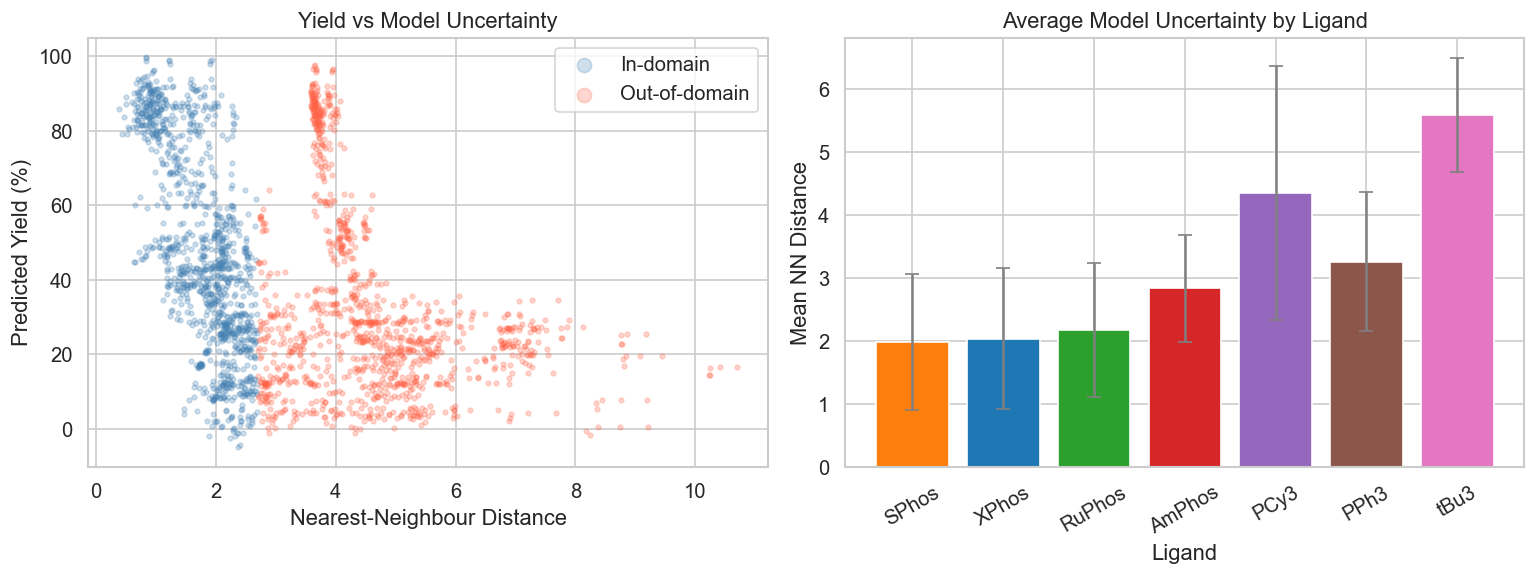

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Yield vs NN distance (scatter, coloured by in/out-of-domain)
ax = axes[0]
for flag, color, label in [(False, "steelblue", "In-domain"), (True, "tomato", "Out-of-domain")]:
    sub = df[df["out_of_domain"] == flag]
    ax.scatter(sub["nn_distance"], sub["predicted_yield"],
               alpha=0.25, s=8, color=color, label=label, rasterized=True)
ax.set_xlabel("Nearest-Neighbour Distance")
ax.set_ylabel("Predicted Yield (%)")
ax.set_title("Yield vs Model Uncertainty")
ax.legend(markerscale=3)

# Mean NN distance per ligand
ax = axes[1]
mean_nn = df.groupby("ligand")["nn_distance"].mean().reindex(order)
std_nn  = df.groupby("ligand")["nn_distance"].std().reindex(order)
ax.bar(mean_nn.index, mean_nn.values, yerr=std_nn.values, capsize=4,
       color=[LIGAND_PALETTE[l] for l in mean_nn.index], error_kw=dict(ecolor="grey"))
ax.set_xlabel("Ligand")
ax.set_ylabel("Mean NN Distance")
ax.set_title("Average Model Uncertainty by Ligand")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## 7. DFT Descriptor Analysis

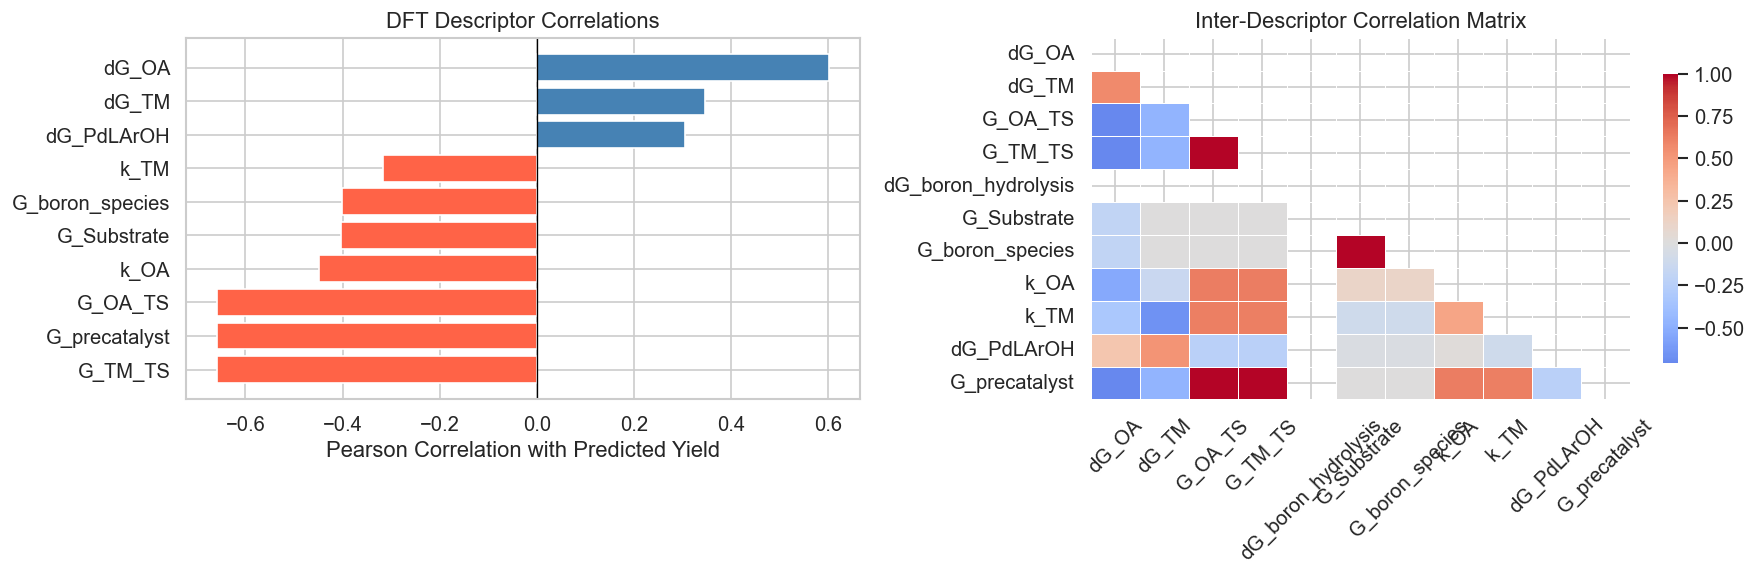

In [17]:
dft_cols = ["dG_OA", "dG_TM", "G_OA_TS", "G_TM_TS",
            "dG_boron_hydrolysis", "G_Substrate", "G_boron_species",
            "k_OA", "k_TM", "dG_PdLArOH", "G_precatalyst"]

# Correlation with predicted_yield
corr = df[dft_cols + ["predicted_yield"]].corr()["predicted_yield"].drop("predicted_yield").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
colors = ["tomato" if v < 0 else "steelblue" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Predicted Yield")
ax.set_title("DFT Descriptor Correlations")

# Correlation matrix heatmap
ax = axes[1]
corr_matrix = df[dft_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, cbar_kws={"shrink": 0.8})
ax.set_title("Inter-Descriptor Correlation Matrix")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

C:\Users\livio\AppData\Local\Temp\ipykernel_37928\3849519750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="ligand", y=col, order=order,
C:\Users\livio\AppData\Local\Temp\ipykernel_37928\3849519750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="ligand", y=col, order=order,
C:\Users\livio\AppData\Local\Temp\ipykernel_37928\3849519750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="ligand", y=col, order=order,
C:\Users\livio\AppData\Local\Temp\ipykernel_37928\3849519750.py:6: FutureWar

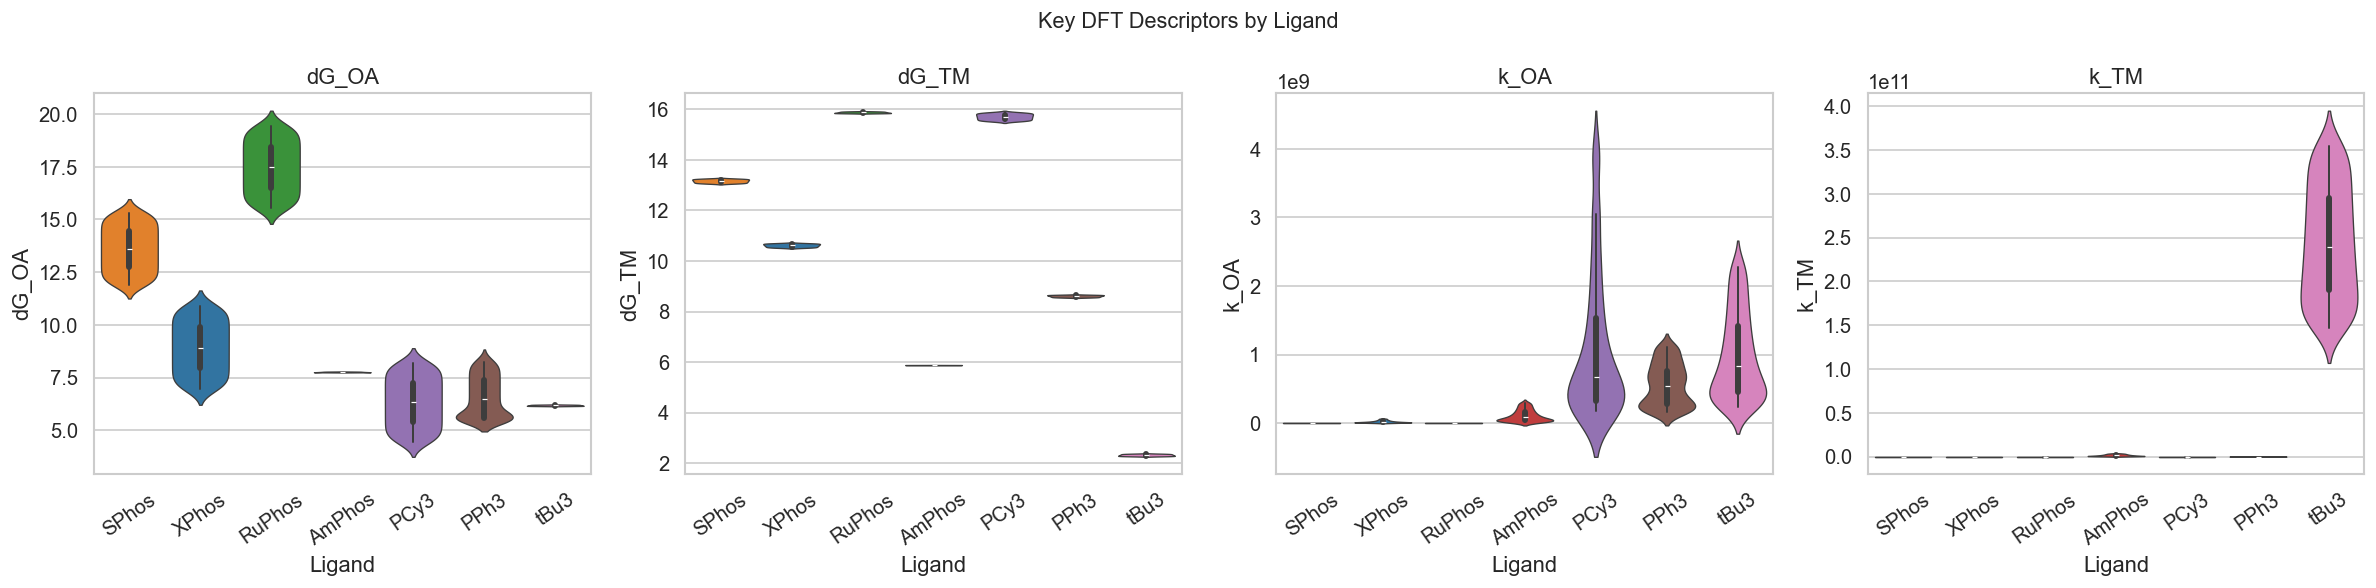

In [18]:
# Violin plots: key descriptors split by ligand
key_desc = ["dG_OA", "dG_TM", "k_OA", "k_TM"]
fig, axes = plt.subplots(1, len(key_desc), figsize=(5 * len(key_desc), 5))

for ax, col in zip(axes, key_desc):
    sns.violinplot(data=df, x="ligand", y=col, order=order,
                   palette=LIGAND_PALETTE, ax=ax, inner="box", linewidth=0.8)
    ax.set_title(col)
    ax.set_xlabel("Ligand")
    ax.tick_params(axis="x", rotation=35)

plt.suptitle("Key DFT Descriptors by Ligand", fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Summary

In [20]:
best_overall   = df.nlargest(1, "predicted_yield").iloc[0]
best_in_domain = df[~df["out_of_domain"]].nlargest(1, "predicted_yield").iloc[0]
best_tradeoff  = pareto_df[~pareto_df["out_of_domain"]].iloc[0]

print("━" * 60)
print("BEST OVERALL PREDICTION")
print(f"  Ligand      : {best_overall['ligand']}")
print(f"  Temperature : {best_overall['temp_c']} °C")
print(f"  Cat loading : {best_overall['cat_loading']} mol%")
print(f"  Time        : {best_overall['time_s']} s")
print(f"  Yield       : {best_overall['predicted_yield']:.2f} %")
print(f"  NN dist     : {best_overall['nn_distance']:.3f}")
print(f"  In-domain   : {not best_overall['out_of_domain']}")
print()
print("━" * 60)
print("BEST IN-DOMAIN PREDICTION (most trustworthy)")
print(f"  Ligand      : {best_in_domain['ligand']}")
print(f"  Temperature : {best_in_domain['temp_c']} °C")
print(f"  Cat loading : {best_in_domain['cat_loading']} mol%")
print(f"  Time        : {best_in_domain['time_s']} s")
print(f"  Yield       : {best_in_domain['predicted_yield']:.2f} %")
print(f"  NN dist     : {best_in_domain['nn_distance']:.3f}")
print()
print("━" * 60)
print("BEST PARETO-OPTIMAL IN-DOMAIN POINT (yield–uncertainty tradeoff)")
print(f"  Ligand      : {best_tradeoff['ligand']}")
print(f"  Temperature : {best_tradeoff['temp_c']} °C")
print(f"  Cat loading : {best_tradeoff['cat_loading']} mol%")
print(f"  Time        : {best_tradeoff['time_s']} s")
print(f"  Yield       : {best_tradeoff['predicted_yield']:.2f} %")
print(f"  NN dist     : {best_tradeoff['nn_distance']:.3f}")
print("━" * 60)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BEST OVERALL PREDICTION
  Ligand      : XPhos
  Temperature : 75 °C
  Cat loading : 2.5 mol%
  Time        : 300 s
  Yield       : 99.82 %
  NN dist     : 0.826
  In-domain   : True

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BEST IN-DOMAIN PREDICTION (most trustworthy)
  Ligand      : XPhos
  Temperature : 75 °C
  Cat loading : 2.5 mol%
  Time        : 300 s
  Yield       : 99.82 %
  NN dist     : 0.826

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BEST PARETO-OPTIMAL IN-DOMAIN POINT (yield–uncertainty tradeoff)
  Ligand      : SPhos
  Temperature : 30 °C
  Cat loading : 0.5 mol%
  Time        : 60 s
  Yield       : -4.31 %
  NN dist     : 2.404
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
